# Why my tree loses to scikit-learn - and fixing it to find out

`02_decision_tree_from_scratch.ipynb` builds an ID3 tree from entropy up and reaches 87.6% on the
test set. `DecisionTreeClassifier` reaches 97.4% on the same split. Ten points.

Chasing a matching number would be the wrong goal - `DecisionTreeClassifier` is not an ID3
implementation. The useful question is **which specific difference costs those ten points**, and
this notebook tests the candidates one at a time: the splitting criterion, the encoding, the size
of the tree, and finally the rule that decides when to stop splitting.

**The last one is the point of having written the algorithm myself.** A stopping rule is one line
inside `build_tree`. I can change it and re-run. With a library that line is not mine to touch.

## Same data, same split

Identical to the previous notebook - shuffle with `random_state=42`, cut at 80%.

In [1]:
import pandas as pd
import math
import time
import numpy as np

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None, names=columns)

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_point = int(len(shuffled_df) * 0.8)
train_df = shuffled_df.iloc[:split_point].reset_index(drop=True)
test_df = shuffled_df.iloc[split_point:].reset_index(drop=True)

target_col = 'class'
attributes = [c for c in train_df.columns if c != target_col]
attribute_values = {attr: sorted(df[attr].unique()) for attr in attributes}

print('Train:', len(train_df), ' Test:', len(test_df))

Train: 1382  Test: 346


### One thing about this dataset that shapes everything below

Car Evaluation is a **complete enumeration**: 4 x 4 x 4 x 3 x 3 x 3 = 1,728, and the file has
exactly 1,728 rows with no repeats. Every possible combination of the six attributes appears once.

So an 80/20 split means **every test row is a combination the tree has never seen.** Nothing can be
answered from memory - the whole test score is generalisation.

In [2]:
n_combinations = 1
for attr in attributes:
    n_combinations *= df[attr].nunique()

print('rows:', len(df))
print('unique attribute combinations:', len(df[attributes].drop_duplicates()))
print('product of value counts:', n_combinations)

rows: 1728
unique attribute combinations: 1728
product of value counts: 1728


## My tree

The functions below come from `02_decision_tree_from_scratch.ipynb` with **one addition**:
`min_samples_leaf`. A split is only allowed if every branch it creates is backed by at least that
many training rows. At `min_samples_leaf=1` nothing is restricted and the tree is identical to the
one in notebook 02 - same accuracy, same leaf count. That default is used for everything up to the
final experiment.

Leaves also carry the number of training rows behind them, which is what the error analysis needs.

In [3]:
import math

def entropy(labels):
    """Shannon entropy of a list/Series of class labels."""
    n = len(labels)
    if n == 0:
        return 0.0
    counts = labels.value_counts()
    ent = 0.0
    for count in counts:
        p = count / n
        ent -= p * math.log2(p)
    return ent


def information_gain(data, attribute, target_col):
    """Information gain from splitting `data` on `attribute`."""
    base_entropy = entropy(data[target_col])
    n = len(data)
    weighted_entropy = 0.0
    for value, subset in data.groupby(attribute):
        weighted_entropy += (len(subset) / n) * entropy(subset[target_col])
    return base_entropy - weighted_entropy


def best_attribute(data, attributes, target_col):
    """Return the attribute (from `attributes`) with the highest information gain."""
    gains = {attr: information_gain(data, attr, target_col) for attr in attributes}
    return max(gains, key=gains.get)


def majority_class(data, target_col):
    """Return the most frequent class label."""
    return data[target_col].value_counts().idxmax()

class Leaf:
    """A leaf, plus how many training rows it was built from."""
    def __init__(self, label, n_rows):
        self.label = label
        self.n_rows = n_rows

def build_tree(data, attributes, target_col, attribute_values, min_samples_leaf=1):
    """
    ID3 tree induction.
    `min_samples_leaf` is the only addition to the version in notebook 02: a split is allowed
    only if every branch it creates has at least this many training rows behind it. At 1 the
    rule never fires and the tree is exactly the one from notebook 02.
    """
    if data[target_col].nunique() == 1:
        return Leaf(data[target_col].iloc[0], len(data))
    if len(attributes) == 0:
        return Leaf(majority_class(data, target_col), len(data))

    # attributes whose split leaves every non-empty branch thick enough
    allowed = []
    for attr in attributes:
        sizes = [len(data[data[attr] == v]) for v in attribute_values[attr]]
        if all(s == 0 or s >= min_samples_leaf for s in sizes):
            allowed.append(attr)

    if not allowed:
        return Leaf(majority_class(data, target_col), len(data))

    attr = best_attribute(data, allowed, target_col)
    remaining_attributes = [a for a in attributes if a != attr]

    tree = {attr: {}}
    parent_majority = majority_class(data, target_col)

    for value in attribute_values[attr]:
        subset = data[data[attr] == value]
        if len(subset) == 0:
            tree[attr][value] = Leaf(parent_majority, 0)
        else:
            tree[attr][value] = build_tree(subset, remaining_attributes, target_col,
                                           attribute_values, min_samples_leaf)
    return tree

In [4]:
def classify(tree, sample):
    """Walk one row from the root to a leaf. Returns (predicted label, rows behind that leaf)."""
    if isinstance(tree, Leaf):
        return tree.label, tree.n_rows
    attr = next(iter(tree))
    return classify(tree[attr][sample[attr]], sample)

def leaf_sizes(tree, out):
    if isinstance(tree, Leaf):
        out.append(tree.n_rows)
        return
    attr = next(iter(tree))
    for sub in tree[attr].values():
        leaf_sizes(sub, out)

def tree_depth(tree):
    if isinstance(tree, Leaf):
        return 0
    attr = next(iter(tree))
    return 1 + max(tree_depth(sub) for sub in tree[attr].values())

In [5]:
start = time.perf_counter()
tree = build_tree(train_df, attributes, target_col, attribute_values)
id3_fit_seconds = time.perf_counter() - start

id3_pred = test_df.apply(lambda row: classify(tree, row)[0], axis=1)
id3_acc = (id3_pred == test_df[target_col]).mean()
id3_train_acc = (train_df.apply(lambda row: classify(tree, row)[0], axis=1) == train_df[target_col]).mean()

sizes = []
leaf_sizes(tree, sizes)
sizes = np.array(sizes)

print('Test accuracy :', round(id3_acc, 4))
print('Train accuracy:', round(id3_train_acc, 4))
print('Depth         :', tree_depth(tree))
print('Leaves        :', len(sizes), ' median rows per leaf:', int(np.median(sizes)),
      ' leaves built from a single row:', int((sizes == 1).sum()))
print('Fit time      :', round(id3_fit_seconds, 3), 'seconds')

Test accuracy : 0.8757
Train accuracy: 1.0
Depth         : 6
Leaves        : 258  median rows per leaf: 1  leaves built from a single row: 125
Fit time      : 0.604 seconds


## Candidate 1 and 2: the criterion and the encoding

`DecisionTreeClassifier` needs numbers, so the categories have to be encoded, and it defaults to
gini rather than entropy. Both are plausible explanations, so both are tested:

- **one-hot** - the neutral treatment. Each split asks "is this attribute equal to this value?"
- **ordinal** - every attribute here has a natural order (`low < med < high`, `2 < 4 < more`), so
  integer codes are defensible and splits become "is this at most k?"
- **entropy**, which is what my ID3 uses, against **gini**, the default.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

y_train, y_test = train_df[target_col], test_df[target_col]

X_train_oh = pd.get_dummies(train_df[attributes])
X_test_oh = pd.get_dummies(test_df[attributes]).reindex(columns=X_train_oh.columns, fill_value=0)

encoder = OrdinalEncoder()
X_train_ord = encoder.fit_transform(train_df[attributes])
X_test_ord = encoder.transform(test_df[attributes])

rows = [{'model': 'ID3 (mine, multi-way)', 'accuracy': id3_acc, 'depth': tree_depth(tree),
         'leaves': len(sizes), 'fit_seconds': id3_fit_seconds}]

for label, Xtr, Xte, criterion in [
    ('sklearn, one-hot, entropy', X_train_oh, X_test_oh, 'entropy'),
    ('sklearn, one-hot, gini', X_train_oh, X_test_oh, 'gini'),
    ('sklearn, ordinal, entropy', X_train_ord, X_test_ord, 'entropy'),
]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    start = time.perf_counter()
    model.fit(Xtr, y_train)
    fit_seconds = time.perf_counter() - start
    rows.append({'model': label, 'accuracy': model.score(Xte, y_test), 'depth': model.get_depth(),
                 'leaves': model.get_n_leaves(), 'fit_seconds': fit_seconds})

results = pd.DataFrame(rows).set_index('model').round(4)
results

,accuracy,depth,leaves,fit_seconds
model,,,,
"ID3 (mine, multi-way)",0.8757,6,258,0.6038
"sklearn, one-hot, entropy",0.9740,14,81,0.0056
"sklearn, one-hot, gini",0.9682,13,92,0.0035
"sklearn, ordinal, entropy",0.9740,13,82,0.0022


**Both ruled out.** Entropy against gini moves accuracy by less than a point; one-hot against
ordinal moves it by nothing. Neither explains ten points.

## Candidate 3: is my tree simply too small?

My tree is 6 levels deep, scikit-learn's is 14, so the obvious next thought is that mine was cut
short. It is worth being careful here, because **depth means different things to the two trees.**
A multi-way split on a four-valued attribute fans out as far in one level as two binary levels do,
so equal depth is not equal size. The comparable budget is the **number of leaves** - how many
pieces the training data ends up cut into.

In [7]:
budget = []
for max_leaves in [13, 16, 30, 81, 258, None]:
    model = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=max_leaves, random_state=42)
    model.fit(X_train_oh, y_train)
    budget.append({'max_leaf_nodes': str(max_leaves), 'accuracy': model.score(X_test_oh, y_test),
                   'leaves_used': model.get_n_leaves(), 'depth': model.get_depth()})

print('My ID3:', round(id3_acc, 4), 'using', len(sizes), 'leaves')
pd.DataFrame(budget).set_index('max_leaf_nodes').round(4)

My ID3: 0.8757 using 258 leaves


,accuracy,leaves_used,depth
max_leaf_nodes,,,
13,0.8382,13,8
16,0.8873,16,8
30,0.9538,30,11
81,0.9682,81,14
258,0.9682,81,14
None,0.9740,81,14


**Ruled out too, and not in my favour.** scikit-learn passes my 87.6% using **16 leaves**. Mine
needed 258. Given a budget of 258 it stops at 81 and does not want more. There is no leaf budget
at which my tree comes out ahead - so "too small" is not the explanation either.

> Note on the last two rows: `max_leaf_nodes=258` gives 96.82% while leaving it unset gives 97.40%,
> even though both end at 81 leaves and depth 14. Setting `max_leaf_nodes` switches scikit-learn
> from depth-first to **best-first** growth, so the same-sized tree is grown in a different order
> and comes out different. The gap is the growth order, not the size.

## Candidate 4: what the errors actually look like

Ruling things out is not an explanation. So instead of comparing totals, here is where my 43 wrong
answers come from - grouped by how many training rows stood behind the leaf that answered them.

In [8]:
records = []
for _, row in test_df.iterrows():
    label, n_rows = classify(tree, row)
    records.append({'rows_behind_leaf': n_rows, 'correct': label == row[target_col]})

errors = pd.DataFrame(records)
errors['bucket'] = pd.cut(errors['rows_behind_leaf'],
                          bins=[-1, 0, 1, 2, 4, 8, 10000],
                          labels=['0 (no training rows)', '1 row', '2 rows', '3-4 rows', '5-8 rows', '9+ rows'])

by_bucket = errors.groupby('bucket', observed=True)['correct'].agg(
    test_rows='size', correct='sum', accuracy='mean').round(3)
by_bucket['wrong'] = by_bucket['test_rows'] - by_bucket['correct']
by_bucket

,test_rows,correct,accuracy,wrong
bucket,,,,
0 (no training rows),23,13,0.565,10
1 row,28,12,0.429,16
2 rows,40,28,0.700,12
3-4 rows,24,20,0.833,4
5-8 rows,27,26,0.963,1
9+ rows,204,204,1.000,0


**Every single error came from a leaf backed by four rows or fewer.** The 204 test rows that
landed on a leaf with nine or more rows behind it were answered correctly, all of them.

And the sharpest line in the table: **a leaf built from one training row is right 42.9% of the
time, which is worse than the 56.5% from leaves with no training rows at all** - those simply
return the parent's majority class. Attaching a single observation to a region makes the tree
*more* wrong than having nothing and falling back on the majority.

That is the mechanism. My tree stops splitting when a region is pure, and **a region holding one
row is pure by definition.** In a complete enumeration that one row is one combination, so the
region looks settled when it has been seen exactly once. 125 of my 258 leaves are built from a
single row; the median leaf holds one. scikit-learn's median leaf holds three.

**A pure region is not a pure rule when the evidence is one observation.**

## Testing that - by changing my own stopping rule

If the diagnosis is right, forbidding thin leaves should recover accuracy. `min_samples_leaf`
does exactly that: it refuses any split that would create a branch with fewer than N training rows
behind it.

The same knob exists in scikit-learn, so both are swept together. If the diagnosis is right, the
constraint should help my tree - which has 125 single-row leaves to fix - and do nothing for
scikit-learn, which barely has the problem.

In [9]:
sweep = []
for m in [1, 2, 3, 5, 10]:
    t_m = build_tree(train_df, attributes, target_col, attribute_values, min_samples_leaf=m)
    acc = (test_df.apply(lambda r: classify(t_m, r)[0], axis=1) == y_test).mean()
    tr_acc = (train_df.apply(lambda r: classify(t_m, r)[0], axis=1) == y_train).mean()
    s = []
    leaf_sizes(t_m, s)
    s = np.array(s)

    sk = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=m, random_state=42).fit(X_train_oh, y_train)
    sk_s = sk.tree_.n_node_samples[sk.tree_.children_left == -1]

    sweep.append({'min_samples_leaf': m,
                  'ID3 test': acc, 'ID3 train': tr_acc,
                  'ID3 leaves': len(s), 'ID3 median rows/leaf': int(np.median(s)),
                  'ID3 single-row leaves': int((s == 1).sum()),
                  'sklearn test': sk.score(X_test_oh, y_test),
                  'sklearn leaves': sk.get_n_leaves(),
                  'sklearn median rows/leaf': int(np.median(sk_s))})

sweep = pd.DataFrame(sweep).set_index('min_samples_leaf').round(4)
sweep

,ID3 test,ID3 train,ID3 leaves,ID3 median rows/leaf,ID3 single-row leaves,sklearn test,sklearn leaves,sklearn median rows/leaf
min_samples_leaf,,,,,,,,
1,0.8757,1.0000,258,1,125,0.9740,81,3
2,0.9133,0.9609,150,3,0,0.9595,70,4
3,0.8671,0.9407,102,4,0,0.9451,61,5
5,0.8555,0.9110,64,9,0,0.9566,47,9
10,0.7803,0.8553,47,13,0,0.9220,37,13


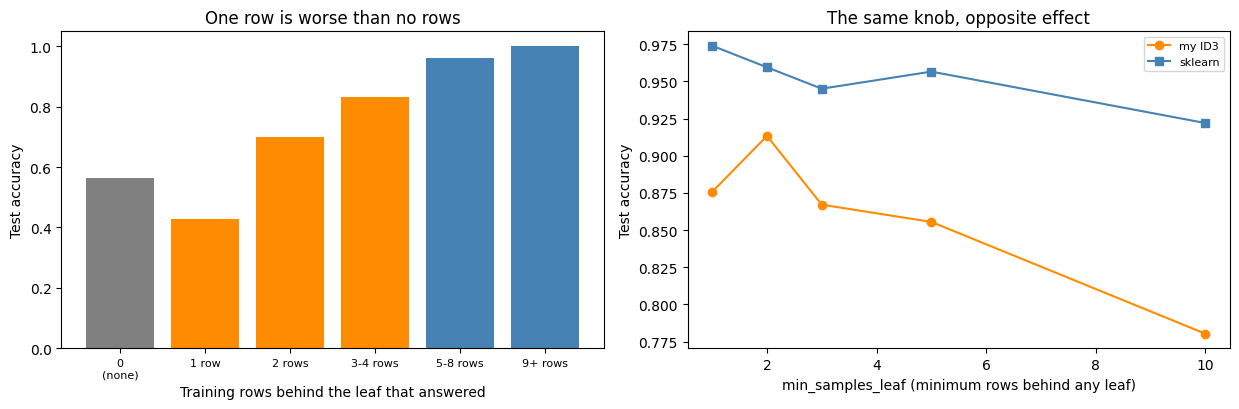

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

acc_by_bucket = by_bucket['accuracy']
axes[0].bar(range(len(acc_by_bucket)), acc_by_bucket.values,
            color=['grey'] + ['darkorange'] * 3 + ['steelblue'] * 2)
axes[0].set_xticks(range(len(acc_by_bucket)))
axes[0].set_xticklabels([s.replace(' (no training rows)', '\n(none)') for s in acc_by_bucket.index],
                        fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Test accuracy')
axes[0].set_xlabel('Training rows behind the leaf that answered')
axes[0].set_title('One row is worse than no rows')

axes[1].plot(sweep.index, sweep['ID3 test'], marker='o', color='darkorange', label='my ID3')
axes[1].plot(sweep.index, sweep['sklearn test'], marker='s', color='steelblue', label='sklearn')
axes[1].set_xlabel('min_samples_leaf (minimum rows behind any leaf)')
axes[1].set_ylabel('Test accuracy')
axes[1].set_title('The same knob, opposite effect')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('images/id3_vs_sklearn.png', dpi=120, bbox_inches='tight')
plt.show()

## So what

**Forbidding the single-row leaf recovers 3.8 points of the gap.** At `min_samples_leaf=2` my tree
goes from 87.6% to 91.3%, single-row leaves drop from 125 to zero, and the median leaf triples from
one row to three. Nothing else about the algorithm changed - one condition in `build_tree`. That is
the diagnosis holding up: the errors were coming from rules built on one observation, and refusing
to build those rules is worth 3.8 points.

**The same knob does nothing for scikit-learn - it only takes accuracy away.** Its median leaf
already holds three rows at `min_samples_leaf=1`, so the constraint has almost nothing to fix and
only removes useful splits. **One algorithm is helped by the exact constraint that hurts the
other**, which is a stronger result than either curve alone: it says the difference between them is
where each naturally stops, not the criterion, the encoding, or the size of the tree.

**And it does not close the gap.** 91.3% against 97.4% - the fix recovers 3.8 of the 9.8 points.
Multi-way splitting also spends its evidence faster than binary splitting does, and one stopping
rule does not undo that. Pruning would be the next thing to try.

**This is the part I could only do because I wrote the algorithm.** The diagnosis needed the row
count behind every leaf, and the test needed the stopping rule to be editable. Both live inside
`build_tree`. Using the library, the ten points would just be the library being better at something
unspecified.

## Limitations

- **Thin leaves and easy regions are confounded.** The 9+ row leaves are largely the big, uniform
  `unacc` regions, so part of "thick leaves are accurate" is "easy regions are large". The
  `min_samples_leaf` sweep is what separates the two - it changes leaf thickness directly and the
  accuracy moves - but the observational table on its own does not.
- One split with one seed, on 1,728 rows. Cross-validation would say whether a 3.8-point gain and a
  9.8-point gap are stable or partly the luck of the shuffle.
- `min_samples_leaf` was swept over five values chosen in advance and the best was read off the
  **test** set. That number is therefore optimistic; a validation split would give an honest one.
- Fit times are reported for scale only. My version runs a pandas `groupby` per node in Python,
  scikit-learn's is compiled. It says nothing about the algorithms.
- Every attribute here is categorical with three or four values, which is what ID3 was designed for.
  With continuous features it would need binning first and the comparison would look different.
- No pruning is implemented, which is the standard remedy for exactly this failure and would
  probably recover more of the gap than a minimum-evidence rule does.